## ANN with no tool

Here well only go over the code and the math behind the ANN that i have implemented. The code is in the file `ANN_noTool.py` and it is a simple implementation of a feedforward neural network with one hidden layer. The code is not optimized for performance and is only meant for my **stupid** barin to understand it.

Btw. this is the tutorial that I followed: [GeeksForGeeks - ANN](https://www.geeksforgeeks.org/deep-learning/building-artificial-neural-networks-ann-from-scratch/)

---

### ReLu activation function

Well use ReLu for activation. You might have the same question as I had, **why do we need to activate the neurons, isn't it enough a "normal" function?** ($ y = w \cdot x + b$). The answer is no, if we don't activate the neurons, the output of the network will be a linear function of the input, and we won't be able to learn complex patterns in the data. It's basicly just a linear regression model.

In the end for aone neuron (e.q IL:n -> HL:m) we have: $$ ReLu(x_n) = max(0, b_{1_n} + x_n \cdot w_{1_{nm}}) $$

---

### Forword propagation

This is the process of calculating the output of the network given an input. We start with the input layer, and we calculate the output of each neuron in the hidden layer using the weights and biases. Then we apply the activation function to the output of each neuron in the hidden layer, and we repeat this process until we reach the output layer.

// TODO: add picture of the forword propagation

---

### Cost function

The cost function we use is the **bynary cross entropy**. This cost function is used for binary classification problems, and it measures the difference between the predicted output and the actual output. The formula for the binary cross entropy is: $$ C = -\frac{1}{N} \sum_{i=1}^{N} [y_i \cdot log(\hat{y}_i) + (1 - y_i) \cdot log(1 - \hat{y}_i)] $$ where $N$ is the number of samples, $y_i$ is the actual output, and $\hat{y}_i$ is the predicted output.

```py
def cost(self, Y, output):
	m = Y.shape[1]
	cost = -np.sum(Y * np.log(output) + (1 - Y) * np.log(1 - output)) / m
	return np.squeeze(cost) # removes any extra dimensions, returning the cost as a scalar
```

---

### Backpropagation

This is the process of calculating the gradients of the cost function with respect to the weights and biases, and then updating the weights and biases using gradient descent. 
$$ \nabla w_{ij} = \eta \cdot \delta_j \cdot y_i $$
$$ \delta_j^{hidden} = \sum_{k} \delta_k^{output} \cdot w_{jk}^{output} \cdot ReLu'(z_j) $$
$$ \delta_j^{output} = \hat{y}_j - y_j $$

```py
def backward(self, X, Y, cache):
	m = Y.shape[1]
	A1 = cache["A1"]
	A2 = cache["A2"]

	# we devide by m because this is a batch
	dZ2 = A2 - Y
	dW2 = np.dot(A1.T, dZ2) / m
	db2 = np.sum(dZ2, axis=0, keepdims=True) / m

	dZ1 = np.dot(dZ2, self.W2.T) * (A1 > 0)
	dW1 = np.dot(X.T, dZ1) / m
	db1 = np.sum(dZ1, axis=0, keepdims=True) / m

	return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
```

In [2]:
from datasets import load_from_disk

dataset = load_from_disk("./data/filtered_dataset") 

In [3]:
import numpy as np
from tqdm import tqdm
import cv2

def normalize_image_to_array(image):
	img = np.array(image).astype(np.uint8)
	img = cv2.resize(img, (64, 64)) # is you fallow thie homework, do this in the database_maker.py when making the dataset, not here
	img_1D = img.flatten()
	return img_1D / 255.0

# dataset = dataset.map(process, num_proc=4)  # uses 4 CPU cores
X = np.array([normalize_image_to_array(img) for img in tqdm(dataset['image'])])
Y = dataset['label']

100%|██████████| 500/500 [08:10<00:00,  1.02it/s]


In [ ]:
from sklearn.model_selection import train_test_split
from ANN_noTool import ANN_noTool

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ann = ANN_noTool()
ann.init_weights(input_size=64*64*3, hidden_size=128, output_size=1)
ann.train(np.array(X_train), np.array(Y_train))

(400, 12288)
(400,)
Epoch 0, Cost: 0.7535
Epoch 100, Cost: 0.5531
Epoch 200, Cost: 0.4717
Epoch 300, Cost: 0.4027
Epoch 400, Cost: 0.3472
Epoch 500, Cost: 0.2849
Epoch 600, Cost: 0.2345
Epoch 700, Cost: 0.1985
Epoch 800, Cost: 0.1691
Epoch 900, Cost: 0.1358


Accuracy: 0.6400
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.79      0.67        47
           1       0.73      0.51      0.60        53

    accuracy                           0.64       100
   macro avg       0.66      0.65      0.64       100
weighted avg       0.66      0.64      0.63       100

Confusion Matrix:


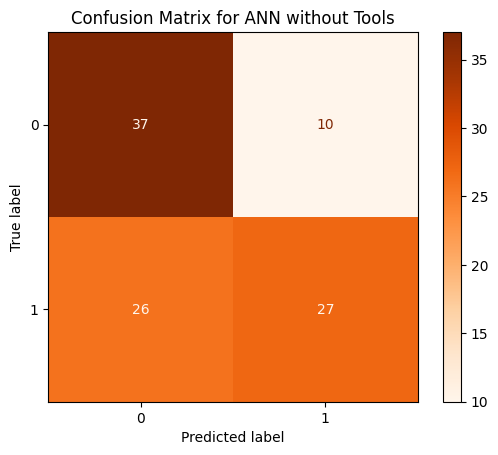

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

predictions = ann.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(Y_test, predictions))
print("Confusion Matrix:")
cm_ann = confusion_matrix(Y_test, predictions)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann).plot(cmap='Oranges')
plt.title("Confusion Matrix for ANN without Tools")
plt.show()

Welp, it's not that good... but now we have to move forward.

---

## CNN with no tool

A CNN (Convolutional Neural Network) is a type of ANN designed to process grid-like data such as images or videos. It uses convolutional and pooling layers to automatically extract features and reduce dimensionality.

Convolutional neural networks have three main kinds of layers, which are:
+ Convolutional layer
+ Pooling layer
+ Fully-connected layer

$$ output = \frac{input - filter + 2 \times padding}{stride} + 1 $$

Our model will have the following architecture:
+ input layer 											-> 64x64x3
+ convolution + ReLu: 32 filters of size 3x3, stride 1 	-> 62x62x32
+ pooling: MaxPool with size 2x2, stride 2 				-> 31x31x32
+ convolution + ReLu: 16 filters of size 2x2, stride 2	-> 29x29x16
+ pooling: MaxPool with size 2x2, stride 2 				-> 14x14x16
+ flatten 												-> 3136
+ fully-connected + ReLu								-> 128	
+ output layer (sigmoid)								-> 1

---

### Forward propagation

A_prev is the input (m, H, W, C):

m -> number of images in the batch (e.g. 32 images at once) <br>
H -> height of the image in pixels (64) <br>
W -> width of the image in pixels (64) <br>
C -> channels (3 for RGB, or 32 after first conv)

W is the filters (f, f, C, num_filters):

f, f -> filter size, e.g. 3x3 — two f's because height and width are the same<br>
C -> each filter must be as deep as the input — if input has 3 channels, the filter is also 3 deep so it looks at R, G, B simultaneously<br>
num_filters -> how many filters (32, 16, etc.)

In [ ]:
import numpy as np

def conv_forward_propagation(A_prev, W, b, stride=1, padding=0):
	m, H_prev, W_prev, C_prev = A_prev.shape
	f, _, C_prev, num_filters = W.shape

	if padding > 0:
		A_prev = np.pad(A_prev, ((0, 0), (padding, padding), (padding, padding), (0, 0)))

	# Calculate output dimensions
	H_out = (H_prev - f + 2 * padding) // stride + 1
	W_out = (W_prev - f + 2 * padding) // stride + 1

	Z = np.zeros((m, H_out, W_out, num_filters)) # output of the convolutional layer

	for i in range(H_out):
		for j in range(W_out):
			h_start = i * stride
			h_end = h_start + f
			w_start = j * stride
			w_end = w_start + f

			A_slice = A_prev[:, h_start:h_end, w_start:w_end, :]
			for k in range(num_filters):
				Z[:, i, j, k] = np.sum(A_slice * W[:, :, :, k], axis=(1, 2, 3)) + b[0, 0, 0, k]
	
	return Z	